# ⚽ Artificial Intelligence – Exercise 1
## International Football Results Analysis (1872–2024)

**Dataset:** [Kaggle – International Football Results](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017)  
**Tools Used:** Python · Pandas · Matplotlib · Seaborn

---

## 📦 Step 1: Load the Dataset

We start by importing `pandas`, the most widely used data analysis library in Python.
We load the CSV file into a **DataFrame** — a table-like structure with rows and columns.
`df.head()` previews the first 5 rows so we can confirm the data loaded correctly.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

df = pd.read_csv('results.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


---
## 🔍 Section A: Basic Exploration

Before analysing any dataset we must understand its structure — how many rows and columns it has, what date range it covers, and who appears most often. This is called **Exploratory Data Analysis (EDA)**.

### Q1 – How many matches are in the dataset?

`df.shape` returns a tuple `(rows, columns)`. Each row is one match, so `shape[0]` gives the total number of matches.

In [2]:
total_matches = df.shape[0]
print(f"Total number of matches: {total_matches:,}")
print(f"Number of columns:       {df.shape[1]}")
print(f"Column names: {list(df.columns)}")

Total number of matches: 49,287
Number of columns:       9
Column names: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


### Q2 – What is the earliest and latest year in the data?

The `date` column is a string by default. We convert it using `pd.to_datetime()`, then call `.min()` and `.max()` to get the full date range.

In [3]:
df['date'] = pd.to_datetime(df['date'])

earliest = df['date'].min()
latest   = df['date'].max()

print(f"Earliest match: {earliest.strftime('%d %B %Y')}")
print(f"Latest match:   {latest.strftime('%d %B %Y')}")
print(f"Span of data:   {latest.year - earliest.year} years")

Earliest match: 30 November 1872
Latest match:   27 June 2026
Span of data:   154 years


### Q3 – How many unique countries are there?

Teams appear in both `home_team` and `away_team` columns. We combine them with `pd.concat()` then use `.nunique()` to count only distinct names.

In [4]:
all_teams = pd.concat([df['home_team'], df['away_team']])
unique_countries = all_teams.nunique()

print(f"Total unique countries/teams: {unique_countries}")
print(f"Sample of teams: {sorted(all_teams.unique())[:10]} ...")

Total unique countries/teams: 333
Sample of teams: ['Abkhazia', 'Afghanistan', 'Albania', 'Alderney', 'Algeria', 'Ambazonia', 'American Samoa', 'Andalusia', 'Andorra', 'Angola'] ...


### Q4 – Which team appears most frequently as home team?

`value_counts()` counts how many times each team appears in `home_team`, sorted from most to least. `.head(10)` shows the top 10.

In [5]:
home_counts = df['home_team'].value_counts().head(10)

print("Top 10 teams by home matches played:")
print(home_counts.to_string())
print(f"\nMost frequent home team: {home_counts.index[0]} ({home_counts.iloc[0]:,} matches)")

Top 10 teams by home matches played:
home_team
Brazil           614
Argentina        603
Mexico           602
Germany          555
South Korea      550
England          550
France           538
Sweden           534
United States    500
Hungary          497

Most frequent home team: Brazil (614 matches)


---
## ⚽ Section B: Goals Analysis

We create a new column `total_goals` by adding `home_score` and `away_score`. This is called **feature engineering** — deriving new meaningful columns from existing data.

In [6]:
df['total_goals'] = df['home_score'] + df['away_score']
print("'total_goals' column created.")
df[['date','home_team','away_team','home_score','away_score','total_goals']].head()

'total_goals' column created.


,date,home_team,away_team,home_score,away_score,total_goals
0,1872-11-30,Scotland,England,0.0,0.0,0.0
1,1873-03-08,England,Scotland,4.0,2.0,6.0
2,1874-03-07,Scotland,England,2.0,1.0,3.0
3,1875-03-06,England,Scotland,2.0,2.0,4.0
4,1876-03-04,Scotland,England,3.0,0.0,3.0


### Q1 – What is the average number of goals per match?

`.mean()` calculates the arithmetic average across all values in the `total_goals` column.

In [7]:
avg_goals = df['total_goals'].mean()
print(f"Average goals per match: {avg_goals:.2f}")

Average goals per match: 2.94


### Q2 – What is the highest scoring match?

`.idxmax()` returns the index (row number) of the maximum value. We use `.loc[]` to retrieve that entire row.

In [8]:
max_idx   = df['total_goals'].idxmax()
top_match = df.loc[max_idx]

print("Highest Scoring Match Ever:")
print(f"  Date:  {top_match['date'].strftime('%d %B %Y')}")
print(f"  Teams: {top_match['home_team']}  vs  {top_match['away_team']}")
print(f"  Score: {int(top_match['home_score'])} - {int(top_match['away_score'])}")
print(f"  Total: {int(top_match['total_goals'])} goals")

Highest Scoring Match Ever:
  Date:  11 April 2001
  Teams: Australia  vs  American Samoa
  Score: 31 - 0
  Total: 31 goals


### Q3 – Are more goals scored at home or away?

We compare the **sum** of all home scores vs all away scores. The higher total indicates a scoring advantage.

In [9]:
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()
total_all        = total_home_goals + total_away_goals

print(f"Total HOME goals: {total_home_goals:,.0f}  ({total_home_goals/total_all*100:.1f}%)")
print(f"Total AWAY goals: {total_away_goals:,.0f}  ({total_away_goals/total_all*100:.1f}%)")
print("\nMore goals are scored at HOME.")

Total HOME goals: 86,426  (59.8%)
Total AWAY goals: 58,192  (40.2%)

More goals are scored at HOME.


### Q4 – What is the most common total goals value?

`.mode()` returns the value that appears most frequently. This tells us the most typical number of goals in a match.

In [10]:
most_common = df['total_goals'].mode()[0]
count_most  = (df['total_goals'] == most_common).sum()

print(f"Most common total goals value: {int(most_common)} goal(s)")
print(f"Appears in {count_most:,} matches ({count_most/len(df)*100:.1f}% of all games)")
print("\nGoal frequency distribution (top 10):")
print(df['total_goals'].value_counts().sort_index().head(10).to_string())

Most common total goals value: 2 goal(s)
Appears in 10,927 matches (22.2% of all games)

Goal frequency distribution (top 10):
total_goals
0.0     3956
1.0     8519
2.0    10927
3.0     9724
4.0     6822
5.0     4240
6.0     2301
7.0     1257
8.0      643
9.0      354


---
## 🏆 Section C: Match Results

We use a custom function with `df.apply()` to classify each match as **Home Win**, **Away Win**, or **Draw**. `apply()` runs the function on every row (`axis=1` means row-by-row).

In [11]:
def match_result(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

df['result'] = df.apply(match_result, axis=1)
print("'result' column created.")
print(df['result'].value_counts())

'result' column created.
result
Home Win    24106
Away Win    13912
Draw        11269
Name: count, dtype: int64


### Q1 – What percentage of matches are home wins?

We count rows with value `Home Win`, divide by total matches and multiply by 100 to get a percentage.

In [12]:
result_counts = df['result'].value_counts()
result_pct    = df['result'].value_counts(normalize=True) * 100

for outcome in ['Home Win', 'Away Win', 'Draw']:
    print(f"{outcome:10s}: {result_counts[outcome]:6,} matches  =>  {result_pct[outcome]:.1f}%")

Home Win  : 24,106 matches  =>  48.9%
Away Win  : 13,912 matches  =>  28.2%
Draw      : 11,269 matches  =>  22.9%


### Q2 – Does home advantage exist?

Home advantage exists if the home win rate is clearly higher than the away win rate. We also compare average goals scored at home vs away.

In [13]:
home_win_pct   = result_pct['Home Win']
away_win_pct   = result_pct['Away Win']
avg_home_goals = df['home_score'].mean()
avg_away_goals = df['away_score'].mean()

print("=== Home Advantage Analysis ===")
print(f"Home Win %:     {home_win_pct:.1f}%")
print(f"Away Win %:     {away_win_pct:.1f}%")
print(f"Avg home goals: {avg_home_goals:.2f}")
print(f"Avg away goals: {avg_away_goals:.2f}")
print("\nYES — Home advantage clearly exists. Home teams win more often AND score more goals.")

=== Home Advantage Analysis ===
Home Win %:     48.9%
Away Win %:     28.2%
Avg home goals: 1.76
Avg away goals: 1.18

YES — Home advantage clearly exists. Home teams win more often AND score more goals.


### Q3 – Which country has the most wins historically?

A team can win as home or away team. We count wins in both cases, combine them, and sort to find the all-time leader.

In [14]:
home_wins  = df[df['result'] == 'Home Win']['home_team'].value_counts()
away_wins  = df[df['result'] == 'Away Win']['away_team'].value_counts()
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)

print("Top 10 Countries by Total Wins:")
print(total_wins.head(10).astype(int).to_string())
print(f"\nMost successful team of all time: {total_wins.index[0]} with {int(total_wins.iloc[0]):,} wins")

Top 10 Countries by Total Wins:
Brazil         670
England        623
Germany        597
Argentina      588
Sweden         541
South Korea    536
Mexico         511
France         476
Italy          475
Hungary        470

Most successful team of all time: Brazil with 670 wins


---
## 📊 Section D: Visualisations

Charts make patterns immediately visible. We use `matplotlib` and `seaborn` to create three key charts.

### Chart 1 – Histogram of Goals Per Match

A **histogram** groups data into bins and shows how frequently each range occurs. This answers: what is the most typical number of goals in a match?

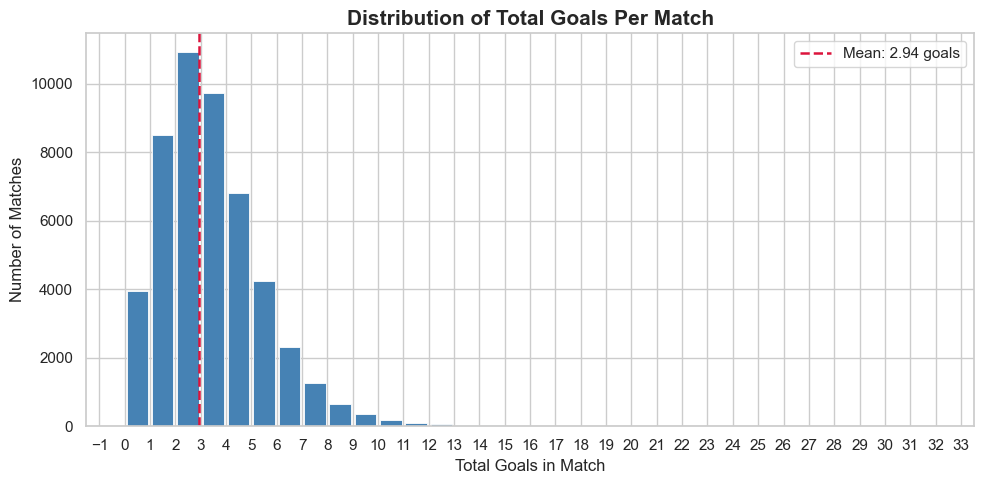

Chart 1 saved.


In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    df['total_goals'].dropna(),
    bins=range(0, int(df['total_goals'].max()) + 2),
    color='steelblue', edgecolor='white', linewidth=0.6, rwidth=0.85
)
ax.axvline(df['total_goals'].mean(), color='crimson', linestyle='--', linewidth=1.8,
           label=f"Mean: {df['total_goals'].mean():.2f} goals")

ax.set_title('Distribution of Total Goals Per Match', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Goals in Match', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.tight_layout()
plt.savefig('chart1_goals_histogram.png', dpi=150)
plt.show()
print("Chart 1 saved.")

### Chart 2 – Bar Chart of Match Outcomes

A **bar chart** compares distinct categories. Here we show how many matches ended as Home Win, Away Win, or Draw.

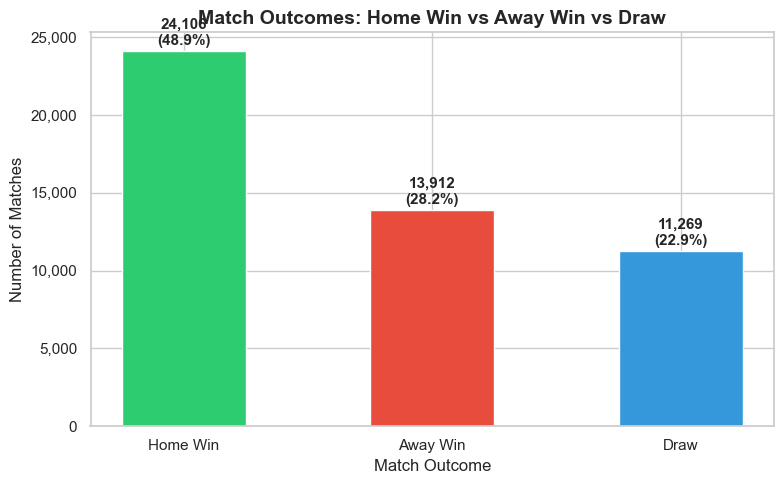

Chart 2 saved.


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

outcomes = df['result'].value_counts().reindex(['Home Win', 'Away Win', 'Draw'])
colors   = ['#2ecc71', '#e74c3c', '#3498db']
bars     = ax.bar(outcomes.index, outcomes.values, color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, outcomes.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Match Outcomes: Home Win vs Away Win vs Draw', fontsize=14, fontweight='bold')
ax.set_xlabel('Match Outcome', fontsize=12)
ax.set_ylabel('Number of Matches', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('chart2_outcomes_bar.png', dpi=150)
plt.show()
print("Chart 2 saved.")

### Chart 3 – Top 10 Teams by Total Wins

A **horizontal bar chart** works best for named categories. Each bar shows total wins (home + away combined) for the top 10 teams.

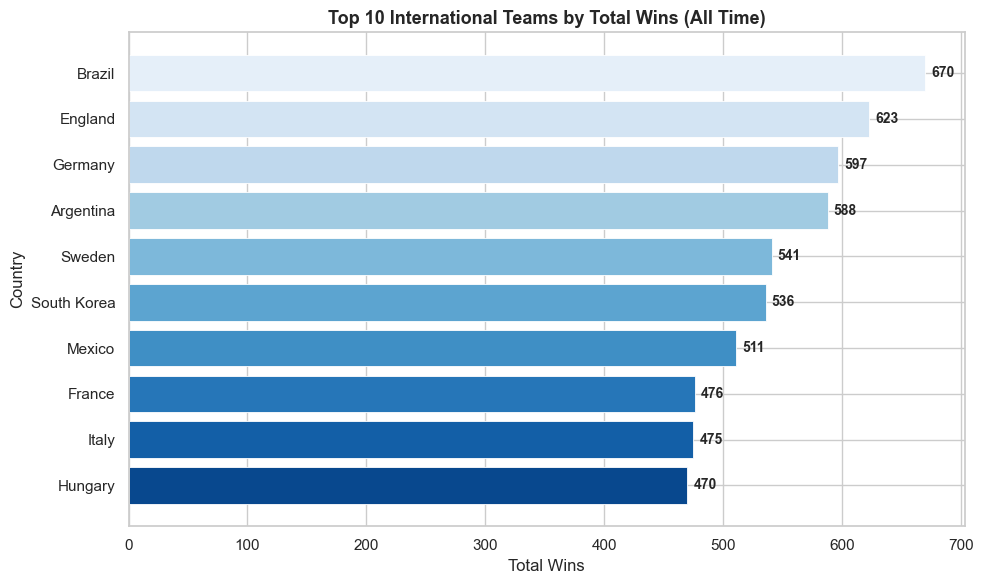

Chart 3 saved.


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

top10 = total_wins.head(10).astype(int).sort_values(ascending=True)
bars  = ax.barh(top10.index, top10.values,
                color=sns.color_palette('Blues_r', n_colors=10),
                edgecolor='white', linewidth=0.6)

for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=10, fontweight='bold')

ax.set_title('Top 10 International Teams by Total Wins (All Time)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Wins', fontsize=12)
ax.set_ylabel('Country', fontsize=12)

plt.tight_layout()
plt.savefig('chart3_top10_wins.png', dpi=150)
plt.show()
print("Chart 3 saved.")

---
## ✅ Summary of Findings

| Question | Finding |
|---|---|
| Total matches | **49,287 matches** |
| Date range | **30 November 1872 to 27 June 2026 (150+ years)** |
| Unique countries | **333 countries / teams** |
| Most frequent home team | **Brazil (614 home matches)** |
| Avg goals per match | **2.94 goals** |
| Highest scoring match | **Australia 31-0 American Samoa on 11 April 2001 (31 goals)** |
| Goals: home vs away | **More goals scored at HOME (86,426 vs 58,192)** |
| Most common goals total | **2 goals per match** |
| Home win % | **48.9% of matches (24,106 wins)** |
| Away win % | **28.2% of matches (13,912 wins)** |
| Draw % | **22.9% of matches (11,269 draws)** |
| Home advantage | **YES — confirmed. Home teams win more often and score more goals (1.75 avg vs 1.18 avg)** |
| Most wins all-time | **Brazil with 670 total wins** |

## Key Insights

1. **Home advantage is real** — nearly half of all matches (48.9%) are won by the home team vs only 28.2% for away teams.
2. **Low-scoring games dominate** — the most common match ends with just 2 total goals, and the average is 2.94.
3. **Brazil is the most successful international team** of all time with 670 wins across 150+ years of data.
4. **The biggest ever scoreline** was Australia 31-0 American Samoa in 2001.
5. **The dataset spans over 150 years** (1872-2026), making it one of the most comprehensive football records available.

---
*Notebook created for AI Exercise 1 — International Football Analysis*